In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import numpy as np

In [2]:
# import data
data = pd.read_csv(r"D:\Willy's Project\Project\Magang Diskominfo\data\result.csv")
data

,title,stars,text,pelayanan,fasilitas,predicted_labels,labels
0,RS Brayat Minulya,5,telah dirawat di sini selama beberapa hari di ...,1,1,"['pelayanan', 'fasilitas']",positive
1,RS Brayat Minulya,5,bersih dan rapi petugas peeawatdokter ditanya ...,1,1,"['pelayanan', 'fasilitas']",positive
2,RS Brayat Minulya,5,terimakasih atas pelayanan dan perawatan ibu s...,1,0,['pelayanan'],positive
3,RS Brayat Minulya,5,pelayanan diruang yosef bagus perawat ramah ra...,1,0,['pelayanan'],positive
4,RS Brayat Minulya,5,tempatnya bagusrapi nyaman sekali ruangan nya ...,1,1,"['pelayanan', 'fasilitas']",positive
...,...,...,...,...,...,...,...
7634,Rumah Sakit Umum Pusat Surakarta,4,lama banget pelayanan untuk pasien baru ibu ny...,1,0,['pelayanan'],negative
7635,Rumah Sakit Umum Pusat Surakarta,4,hospital yg sangat rapi pelayanan bagus,1,1,"['pelayanan', 'fasilitas']",positive
7636,Rumah Sakit Umum Pusat Surakarta,4,khusus paru,0,0,[],positive
7637,Rumah Sakit Umum Pusat Surakarta,5,rs paru,0,0,[],neutral


In [3]:
# rubah nama labels menjadi sentiment
data.rename(columns={'labels': 'sentiment'}, inplace=True)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7639 entries, 0 to 7638
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             7639 non-null   object
 1   stars             7639 non-null   int64 
 2   text              7639 non-null   object
 3   pelayanan         7639 non-null   int64 
 4   fasilitas         7639 non-null   int64 
 5   predicted_labels  7639 non-null   object
 6   sentiment         7639 non-null   object
dtypes: int64(3), object(4)
memory usage: 417.9+ KB


In [5]:
data['title'].value_counts()

title
RUMAH SAKIT Dr. OEN KANDANG SAPI SOLO         2248
RS Brayat Minulya                             1106
RS Panti Waluyo Yakkum Surakarta              1054
RSUD Bung Karno Kota Surakarta                 820
RS Triharsi                                    782
RSUD Ibu Fatmawati Soekarno Kota Surakarta     606
RST Slamet Riyadi                              532
Rumah Sakit Umum Pusat Surakarta               491
Name: count, dtype: int64

hapus beberapa kata yang tidak perlu

In [6]:
import re

# daftar kata
stopwords = ['saya', 'yg', 'dan', 'yang', 'di', 'tidak', 'juga', 'utk', 'itu',
             'untuk', 'juga', 'jg', 'nya', 'tapi', 'tp', 'ga', 'gak', 'ngga', 'nggak', 'sy', 'lagi',
             'lg', 'dengan', 'dgn', 'dg', 'ini', 'kami', 'apa', 'ada', 'ke', 'ya', 'dong', 'sgt', 'bgt',
             'karena', 'krn', 'sebagai', 'sbg']

def remove_stopwords(text):
    if isinstance(text, str):
        pattern = r'\b(?:' + '|'.join(stopwords) + r')\b'
        return re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
    return text

In [7]:
# apply function
data['text'] = data['text'].apply(remove_stopwords)

# Wordcloud

## Wordcloud Umum

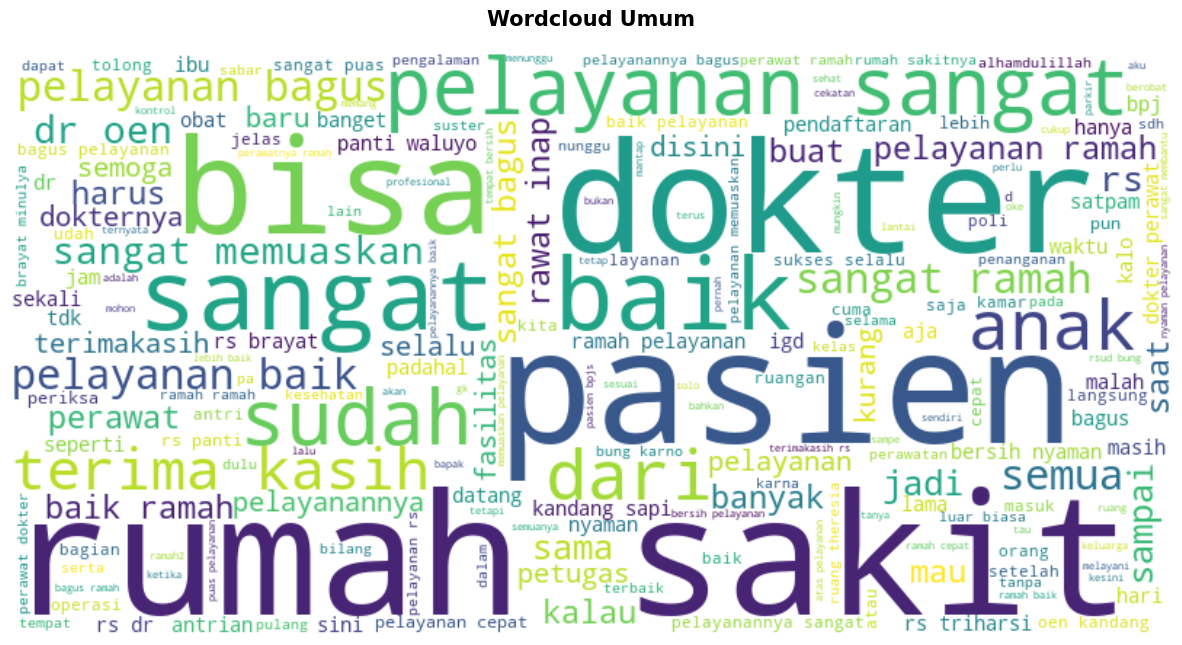

In [8]:
plt.figure(figsize=(15, 10))
# dropna
reviews = data['text'].dropna()
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(reviews))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Wordcloud Umum", fontsize=15, fontweight='bold', pad=20)
plt.show()

## Wordcloud Tiap RS

In [9]:
def wordclouds(data):
    rs = data['title'].unique()

    # looping
    for i in rs:
        # filter
        per_rs = data[data['title'] == i]
        reviews = per_rs['text'].dropna()

        plt.figure(figsize=(15, 10))

        # gabungkan semua teks
        review_combined = " ".join(reviews)

        # wordcloud
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color="white",
            max_words=150,
            colormap='viridis'
        ).generate(review_combined)

        # plot
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Wordcloud {i}", fontsize=15, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

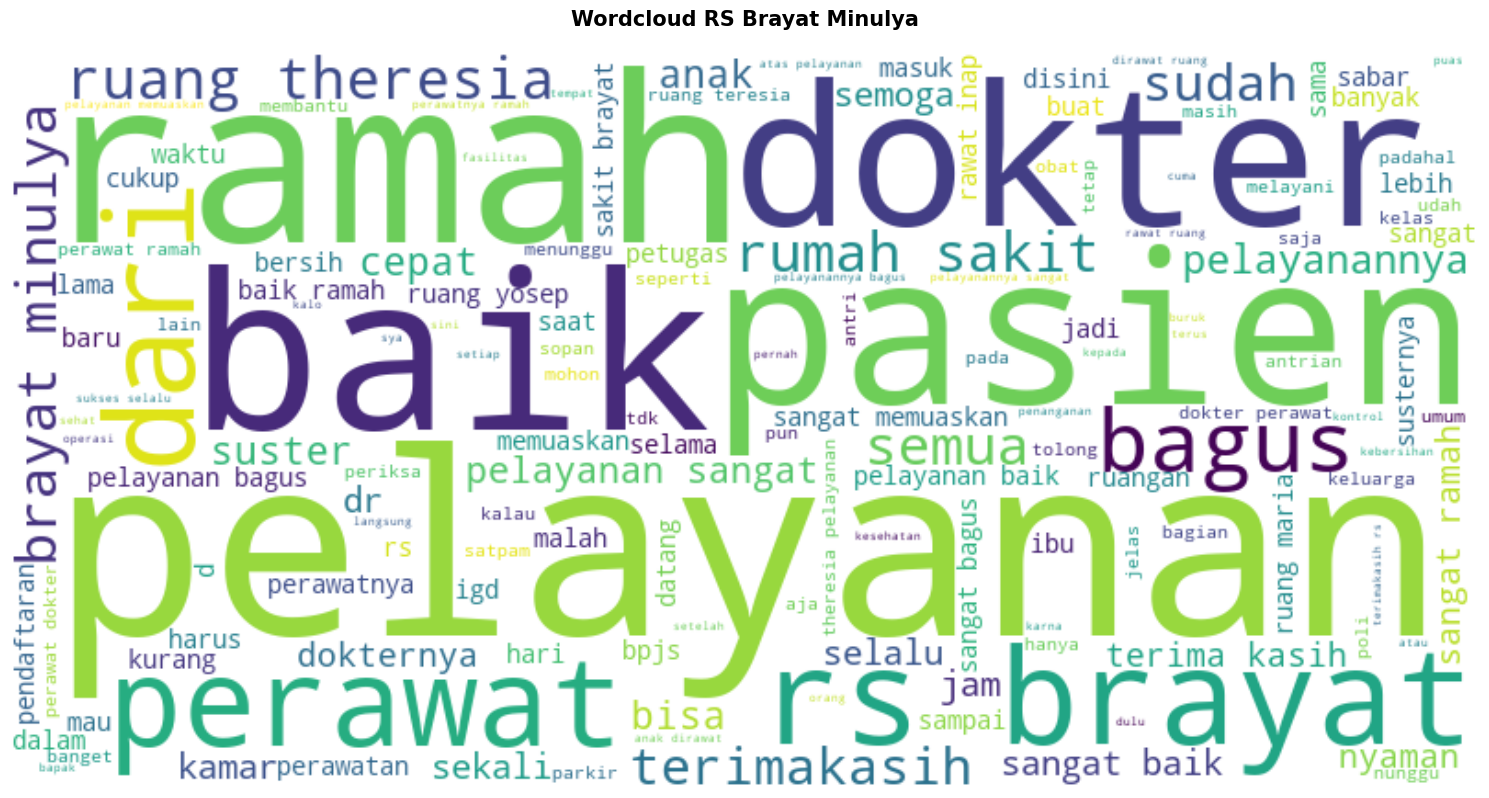

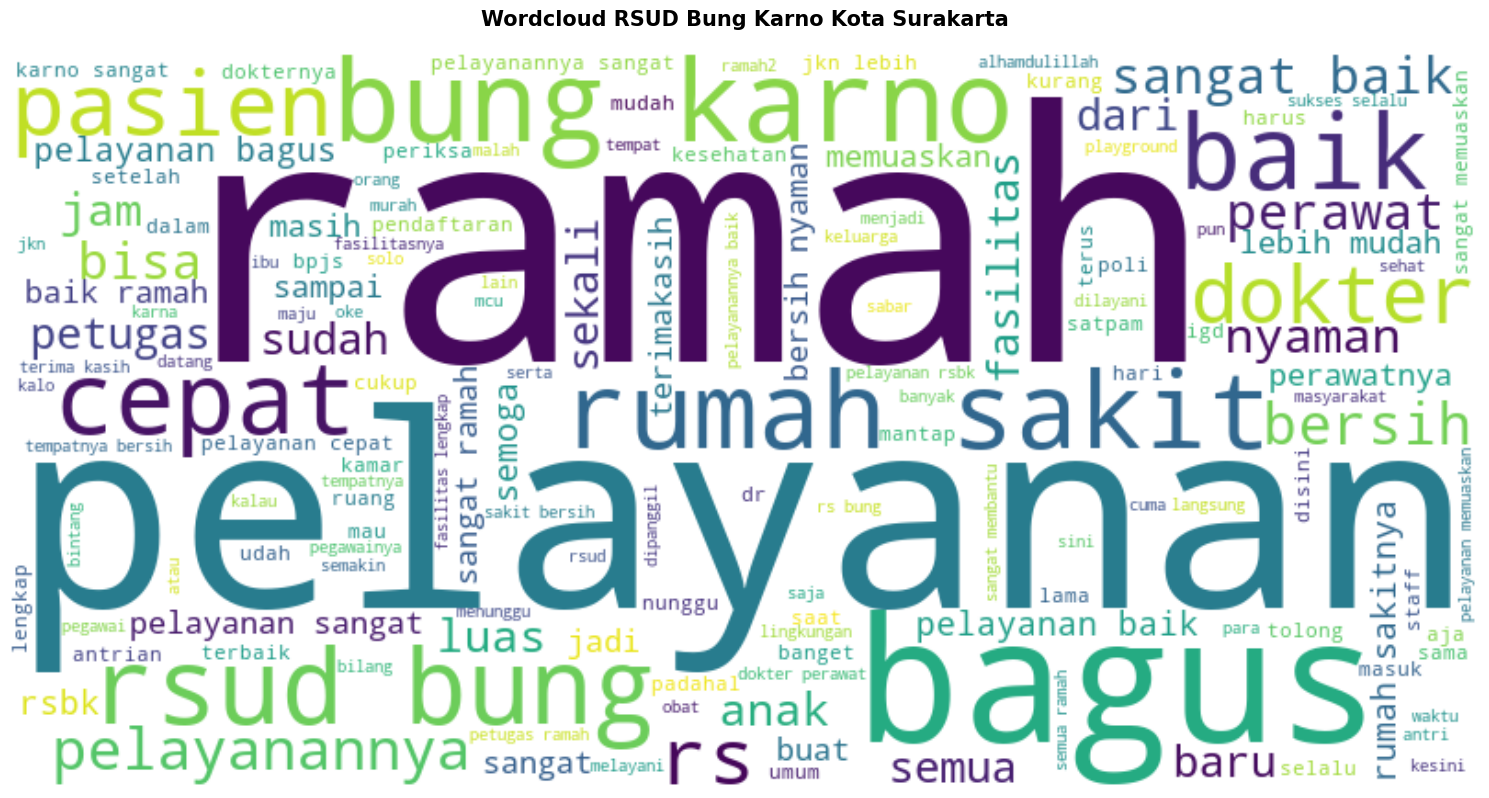

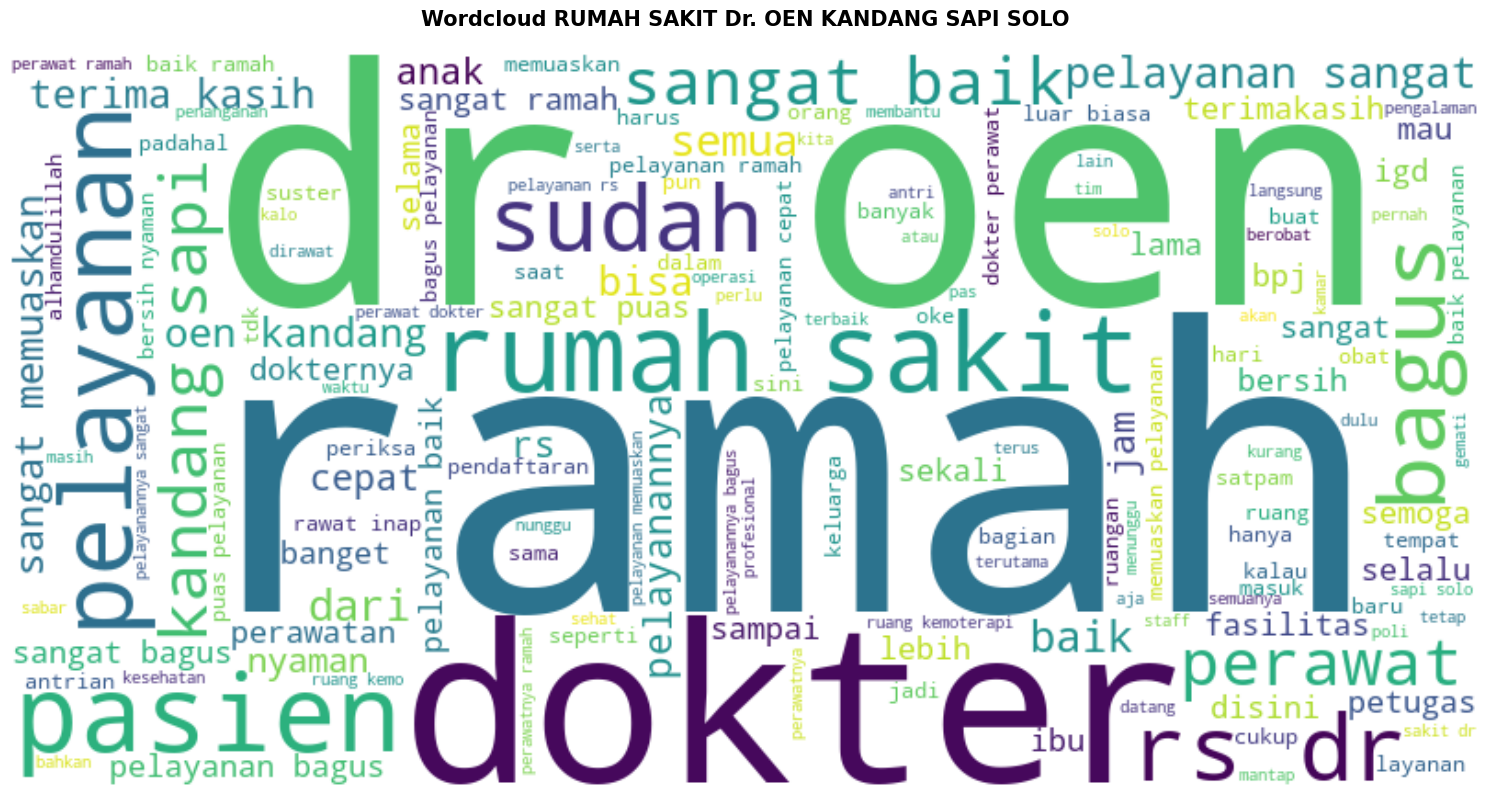

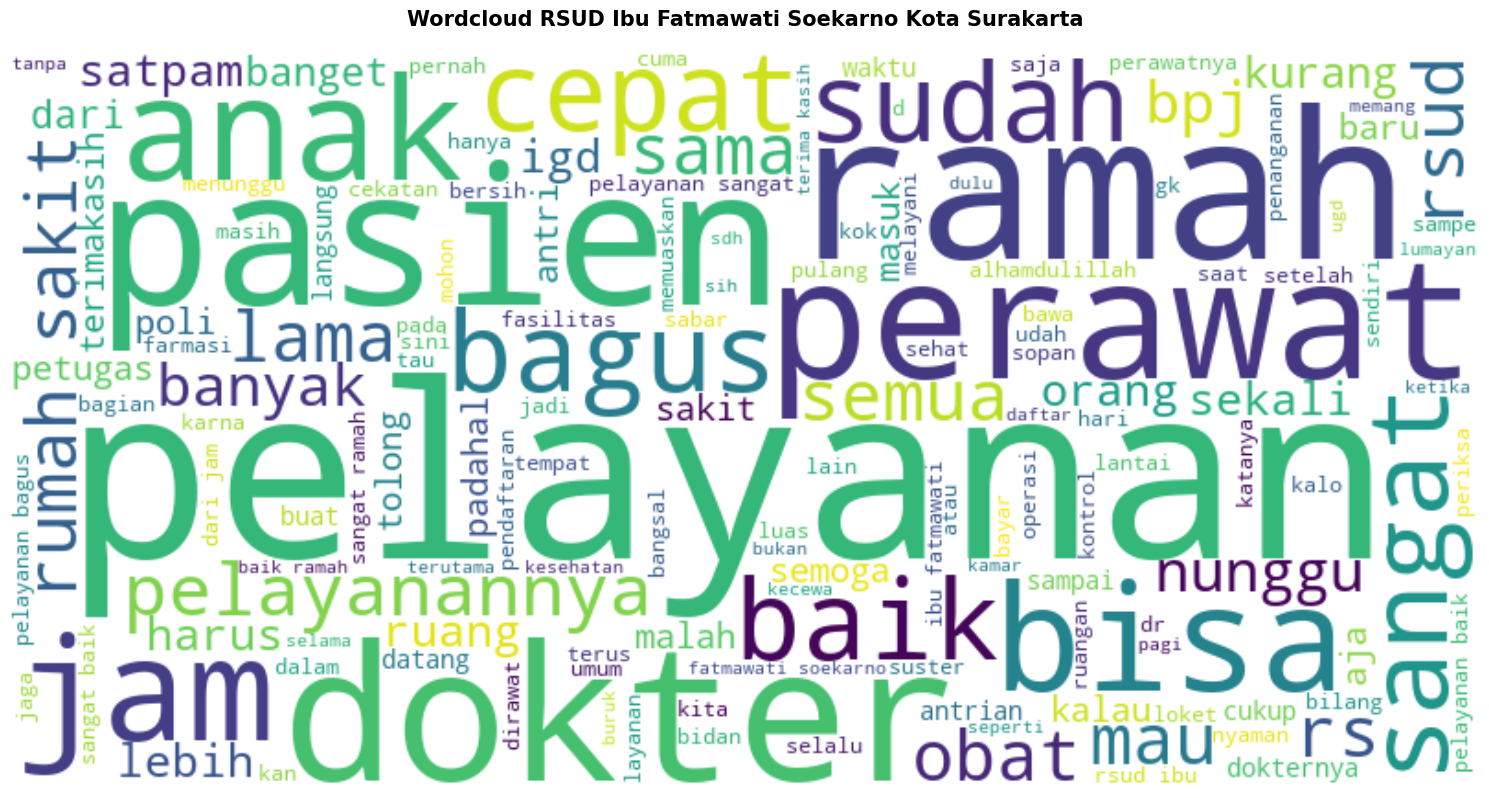

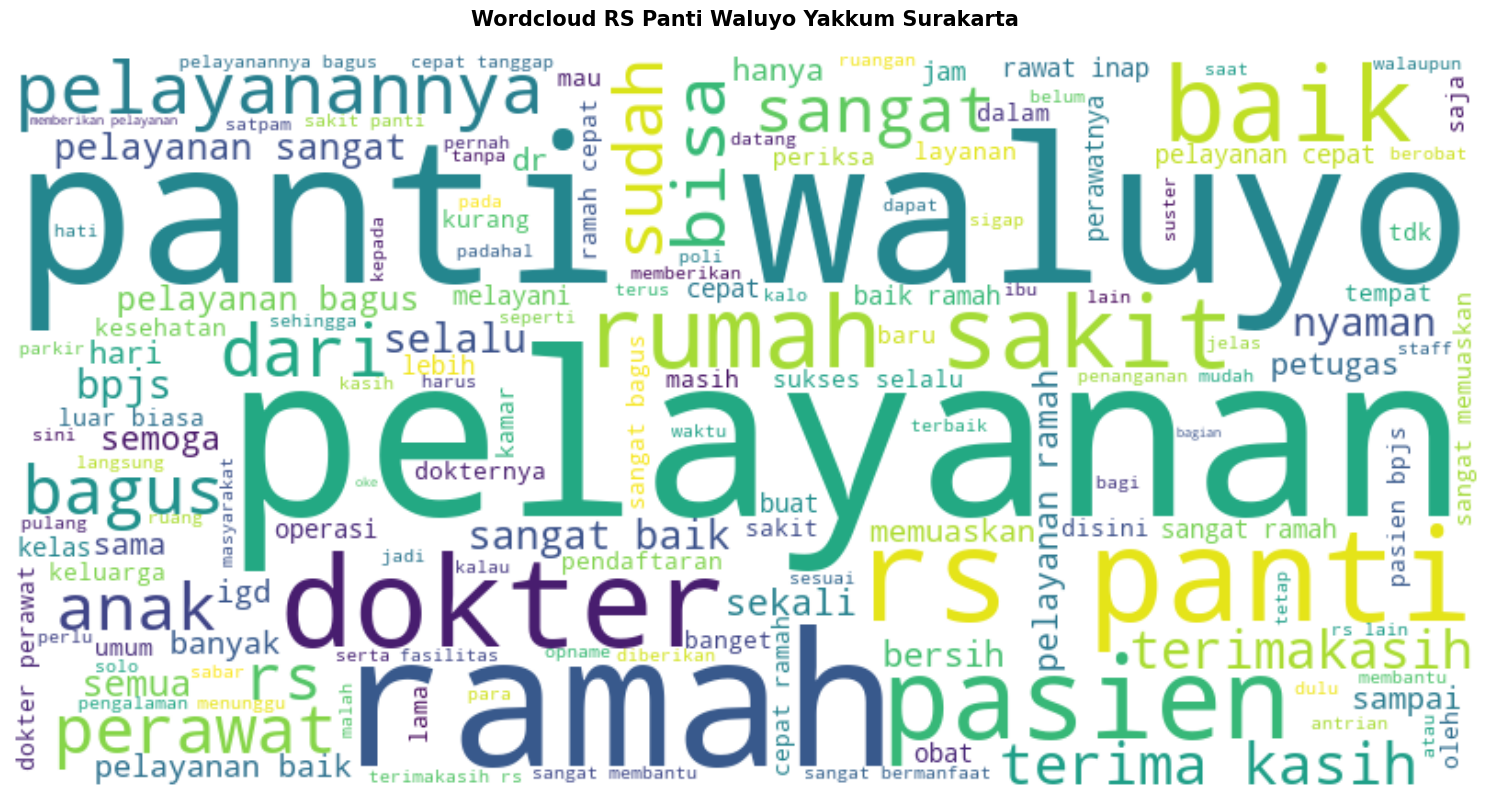

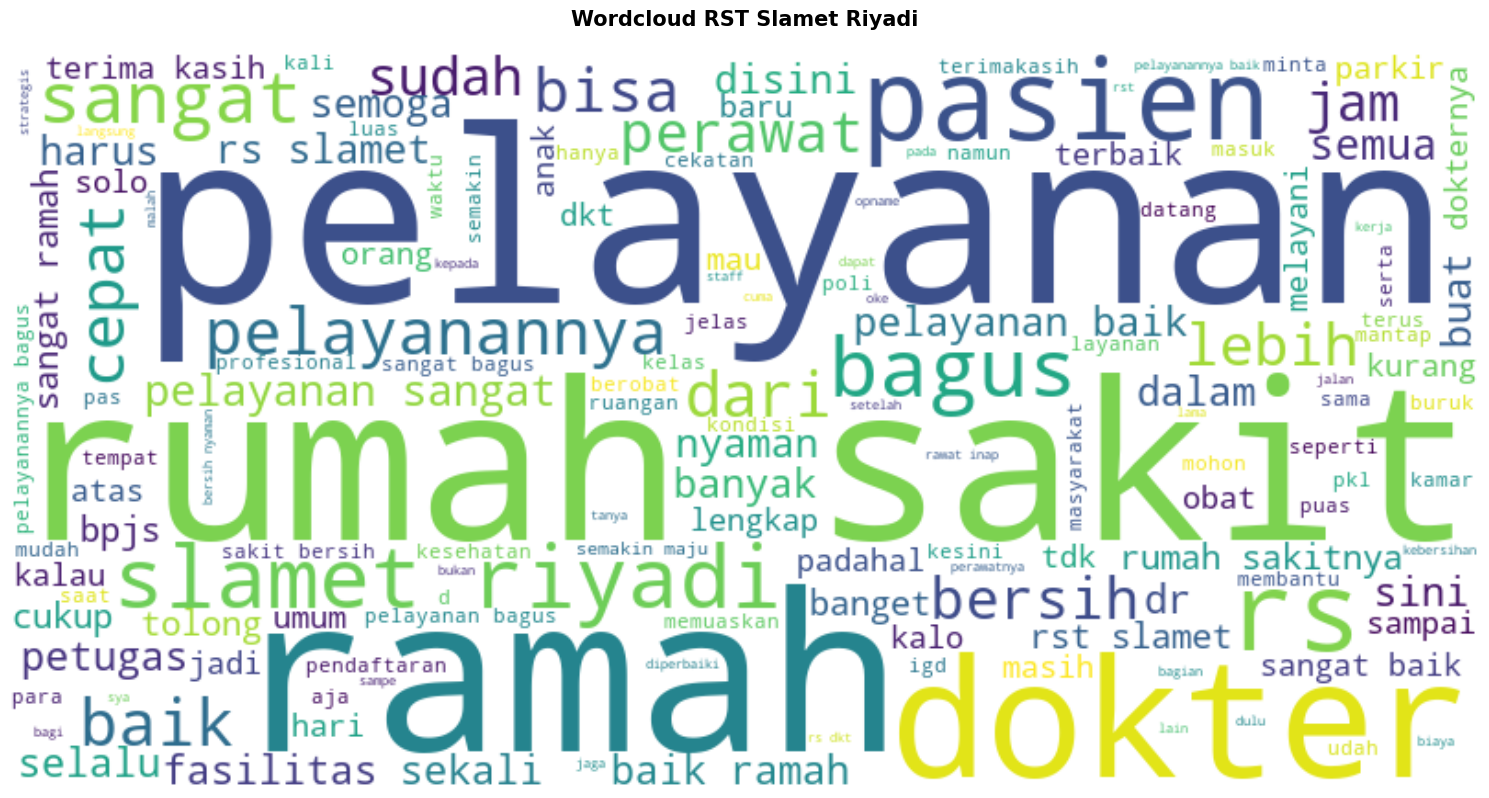

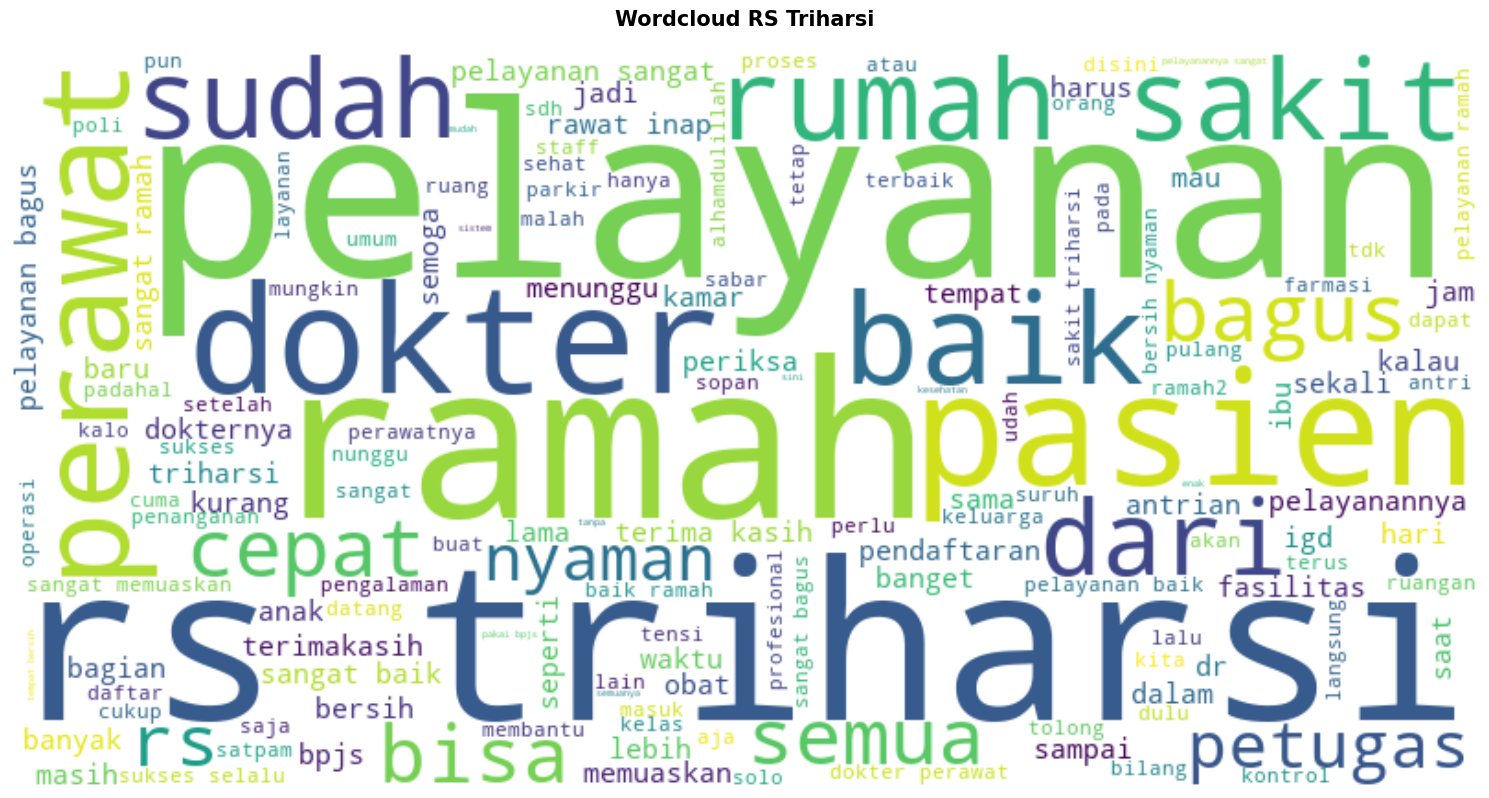

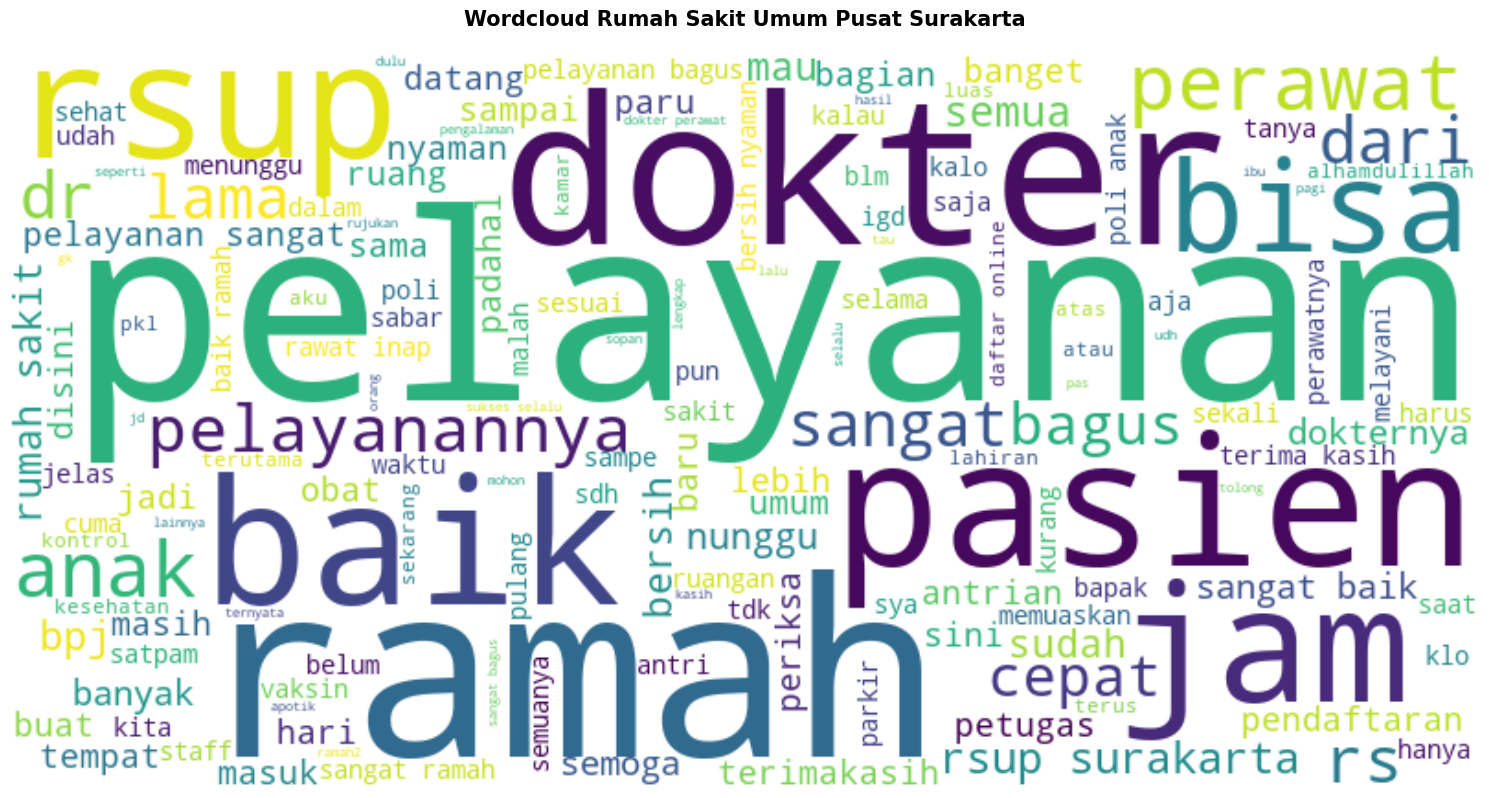

In [10]:
# apply
wordclouds(data)

# Bar Chart

## Bar Chart Umum

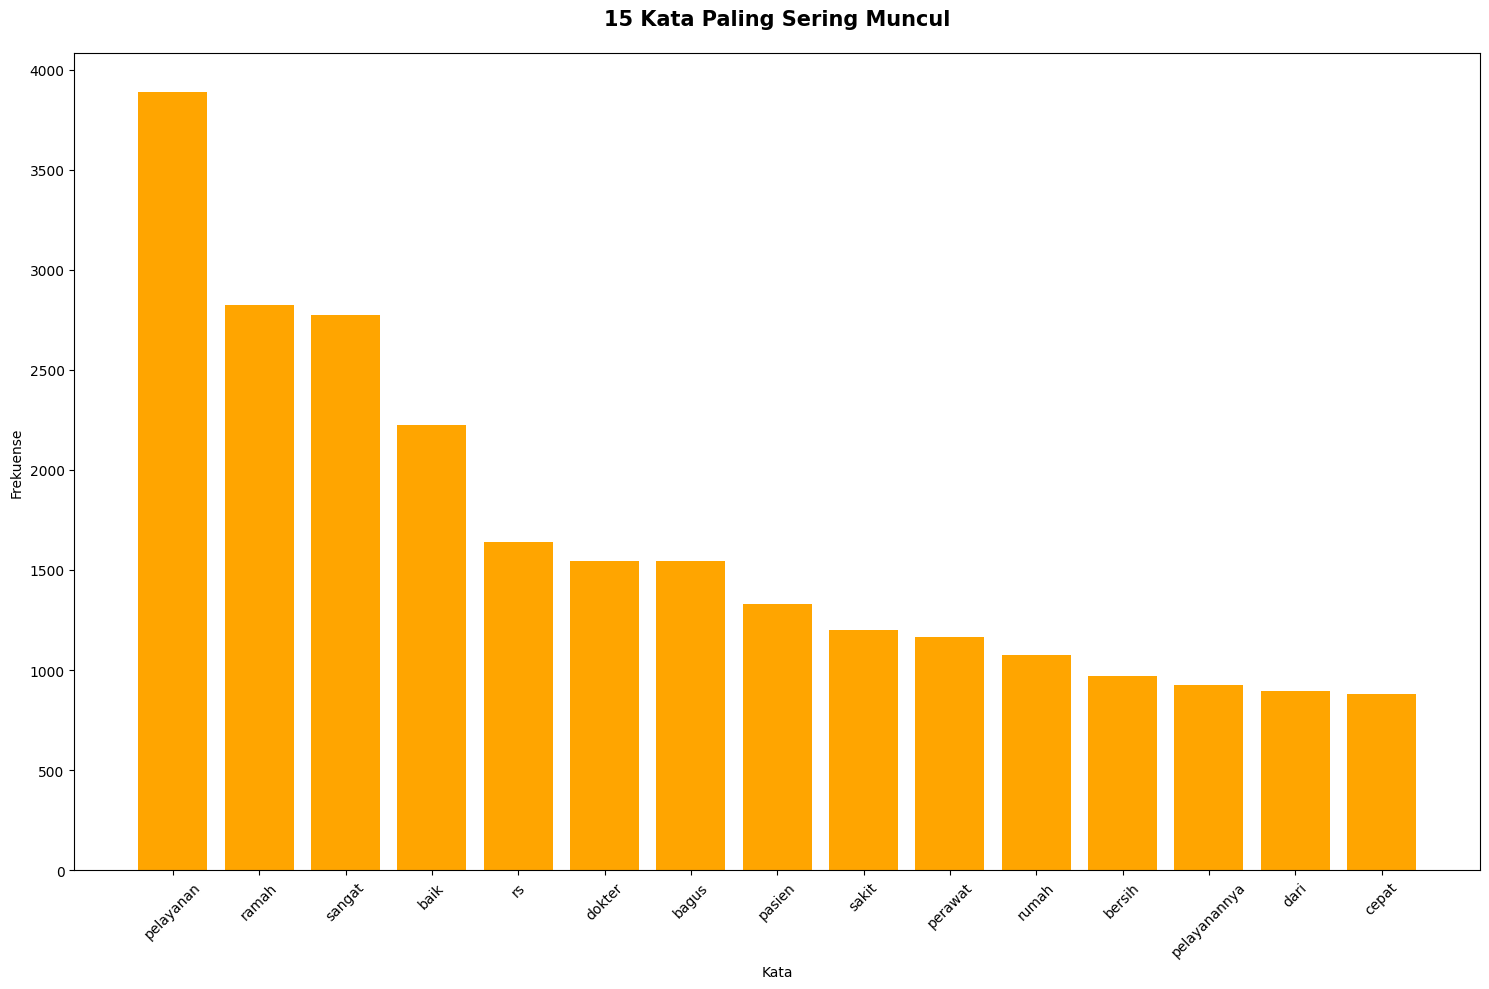

In [11]:
top_n = 15

reviews = data['text'].dropna()
all_text = " ".join(reviews)
words = all_text.split()
word_counts = Counter(words)
most_common_words = word_counts.most_common(top_n)

words_bar, counts_bar = zip(*most_common_words)

plt.figure(figsize=(15, 10))
plt.bar(words_bar, counts_bar, color = 'orange')
plt.xlabel('Kata')
plt.ylabel('Frekuense')
plt.title(f'{top_n} Kata Paling Sering Muncul', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Bar Chart tiap RS

In [12]:
def bar_chart(data):
    rs = data['title'].unique()

    for i in rs:
        per_rs = data[data['title'] == i]
        reviews = per_rs['text'].dropna()
        review_combines = " ".join(reviews)

        words = review_combines.split()
        word_counts = Counter(words)
        most_common = word_counts.most_common(10)

        if most_common:
            # unpacking tuple, words_bar = daftar kata ; counts_bar = frekuensi
            words_bar, counts_bar = zip(*most_common)
            plt.figure(figsize=(10, 6))
            plt.bar(words_bar, counts_bar, color='skyblue')
            plt.xlabel('Kata')
            plt.ylabel('Frekuense')
            plt.title(f"10 Kata Paling Sering Muncul pada {i}", fontsize=15, fontweight='bold', pad=20)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

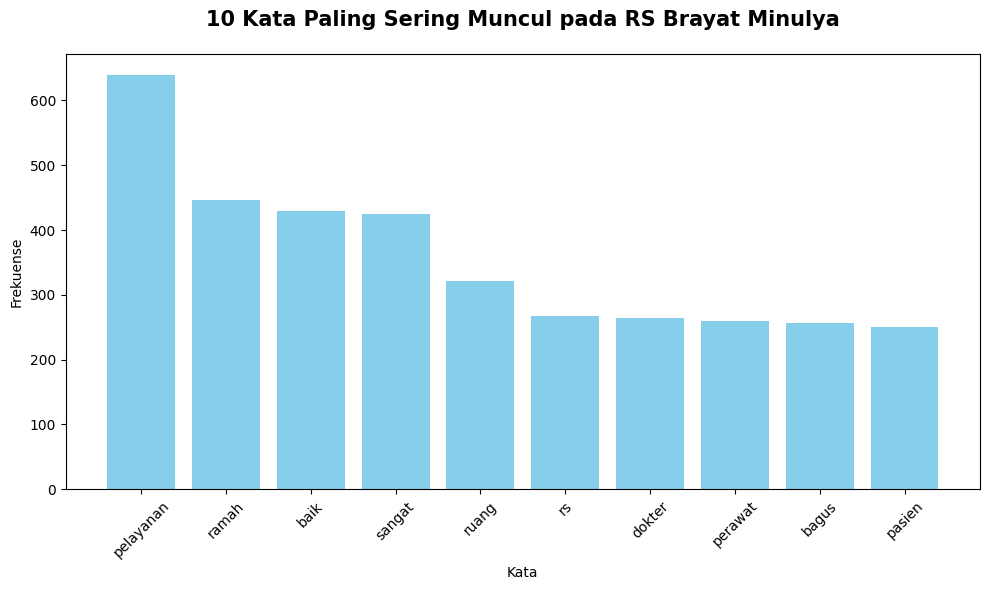

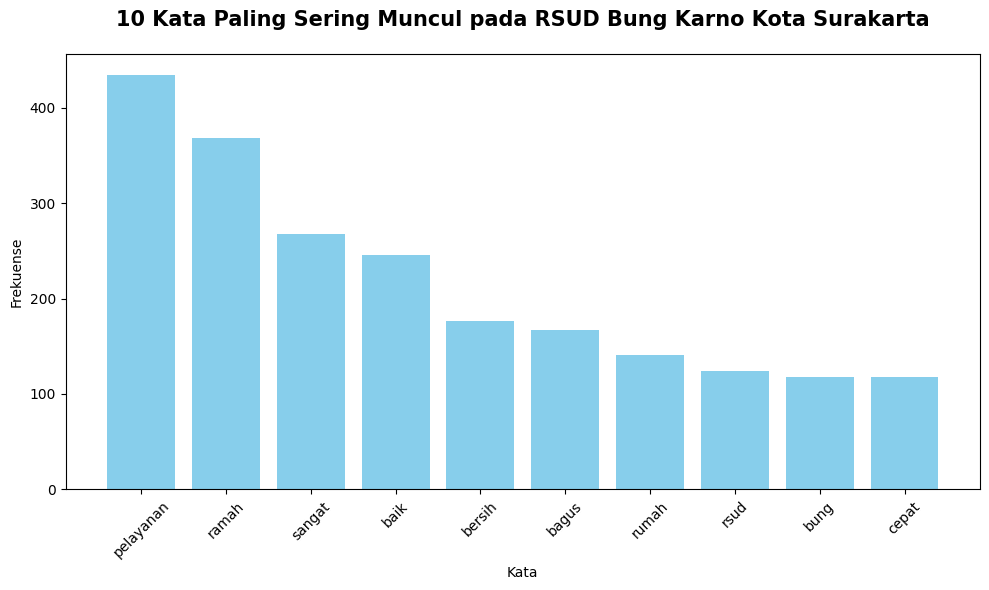

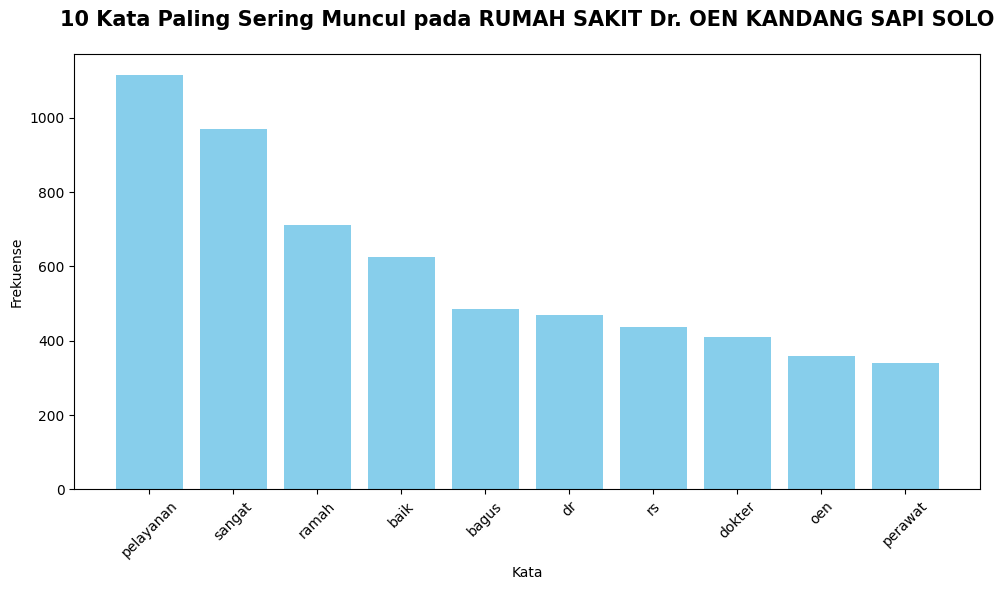

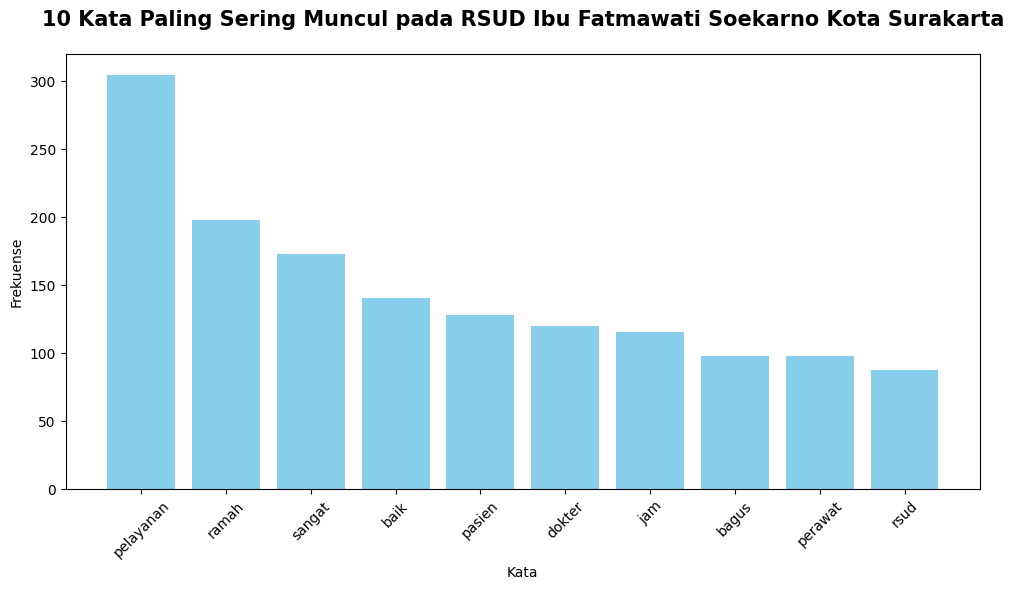

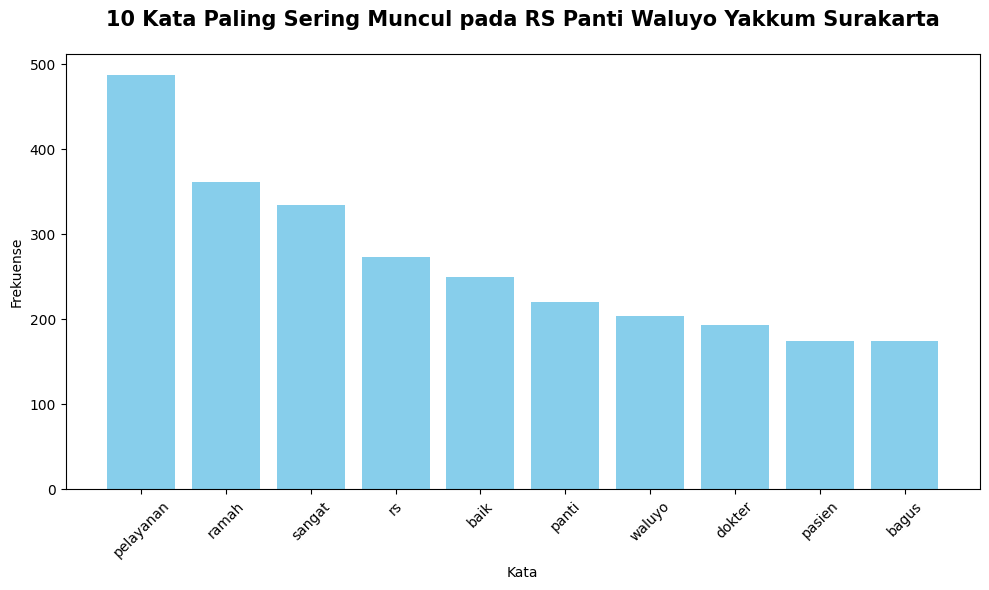

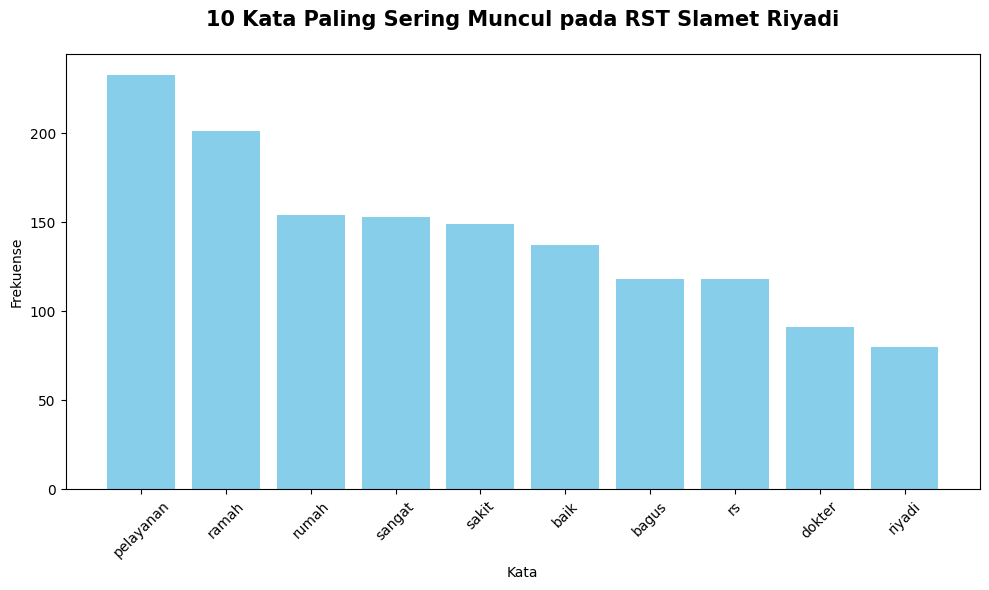

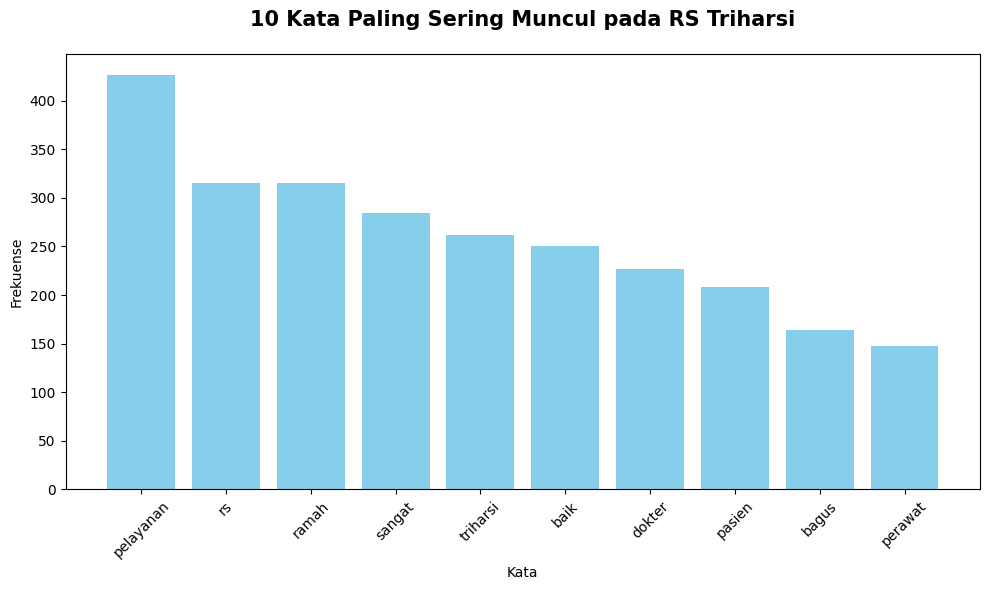

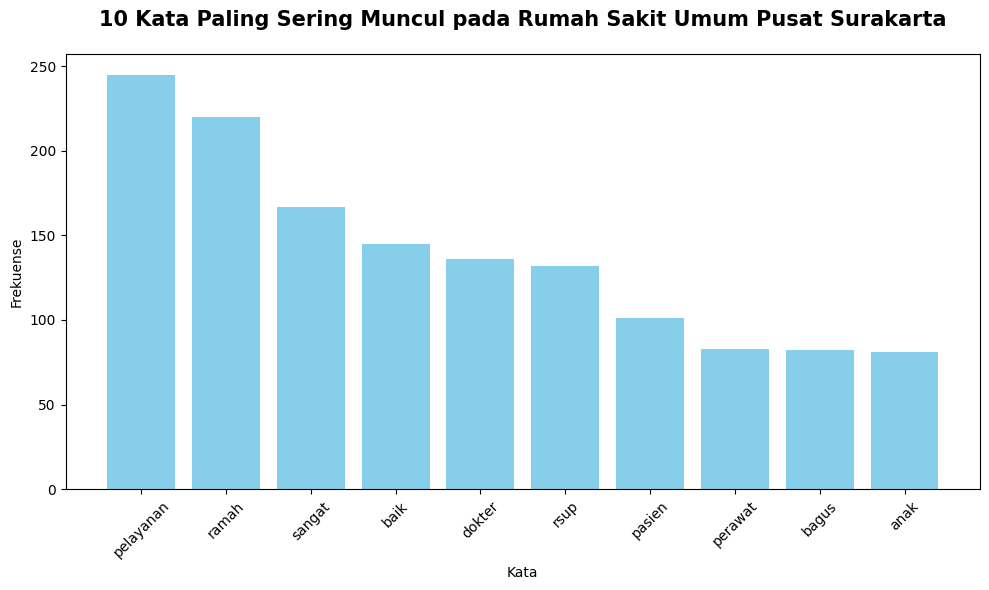

In [13]:
bar_chart(data)

# Distribusi Sentimen

- Distribusi sentimen secara umum  
- Distribusi sentimen tiap rumah sakit 
- Pie chart

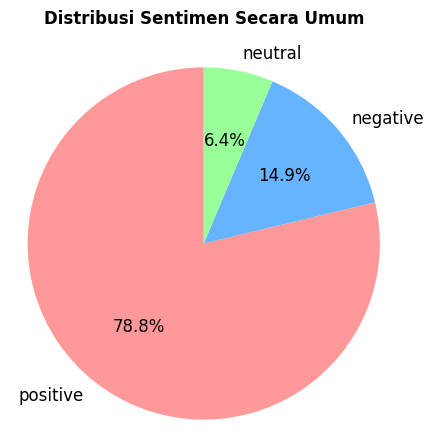

Jumlah data per sentimen:
positive: 6017 (78.8%)
negative: 1135 (14.9%)
neutral: 487 (6.4%)


In [14]:
# Pie Chart Distribusi Sentimen Umum
sentiment_counts = data['sentiment'].value_counts()

plt.figure(figsize=(5, 5))
colors = ['#ff9999', '#66b3ff', '#99ff99']  # warna untuk setiap sentimen
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, textprops={'fontsize': 12})
plt.title('Distribusi Sentimen Secara Umum', fontsize=12, fontweight='bold', pad=20)
plt.axis('equal')  # membuat pie chart berbentuk lingkaran sempurna
plt.show()

print("Jumlah data per sentimen:")
for sentiment, count in sentiment_counts.items():
    print(f"{sentiment}: {count} ({count/len(data)*100:.1f}%)")

## Distribusi sentimen di setiap rumah sakit

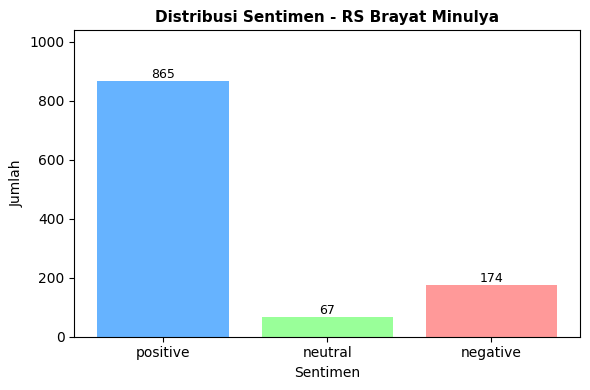

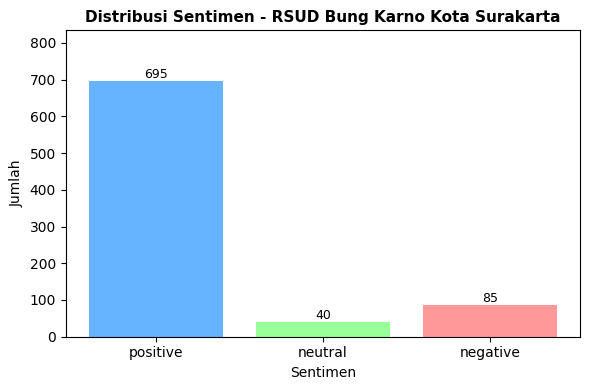

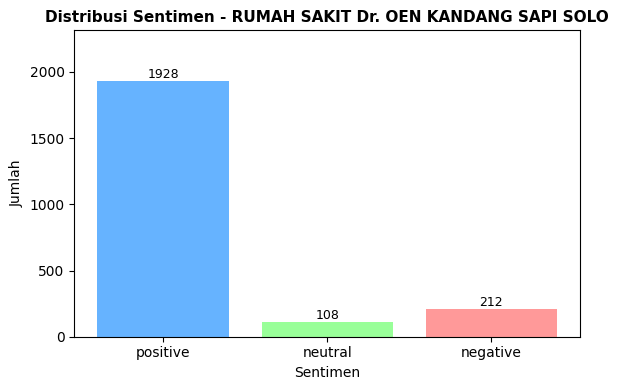

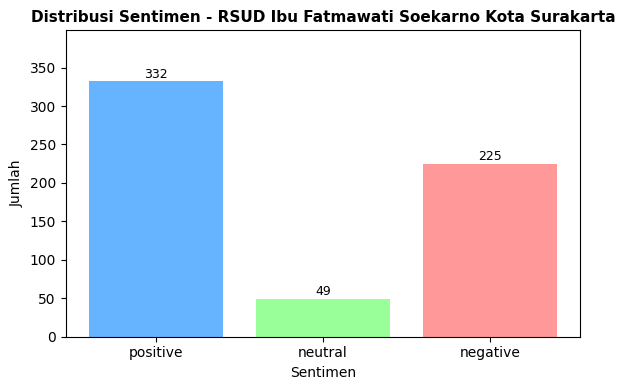

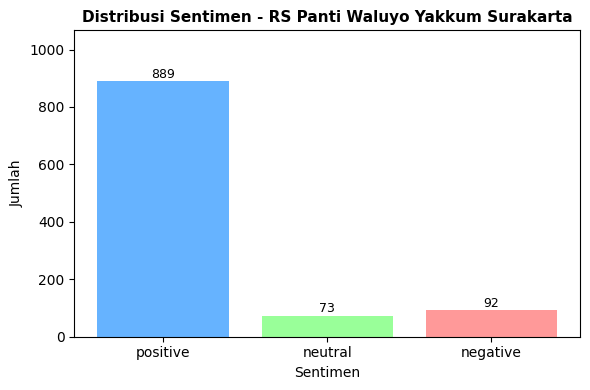

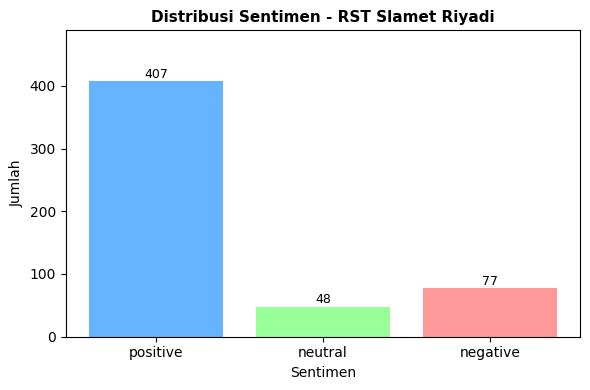

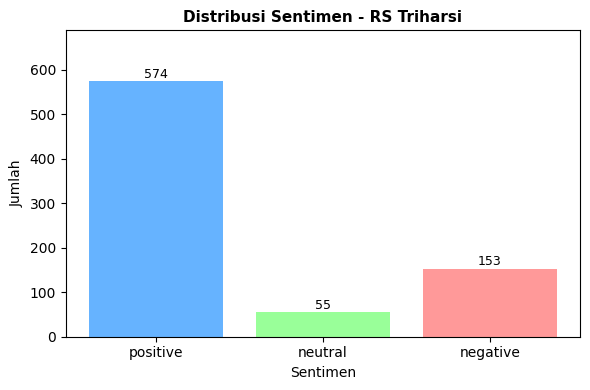

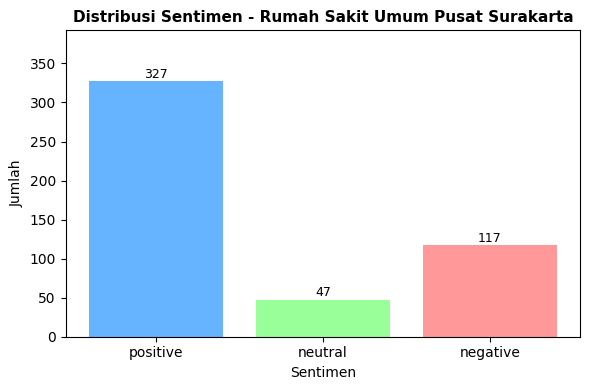

In [29]:
import matplotlib.pyplot as plt

def bar_chart_sentiment_per_rs(data):
    rs_list = data['title'].unique()
    colors = {'positive': '#66b3ff', 'neutral': '#99ff99', 'negative': '#ff9999'}
    
    for rs in rs_list:
        # Filter data per RS
        rs_data = data[data['title'] == rs]
        sentiment_counts = rs_data['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'], fill_value=0)
        
        # Plot bar chart
        plt.figure(figsize=(6, 4))
        bars = plt.bar(sentiment_counts.index, sentiment_counts.values, 
                       color=[colors[s] for s in sentiment_counts.index])
        
        # Tambahkan label di atas bar
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), 
                     ha='center', va='bottom', fontsize=9)

        plt.title(f'Distribusi Sentimen - {rs}', fontsize=11, fontweight='bold')
        plt.xlabel('Sentimen')
        plt.ylabel('Jumlah')
        plt.ylim(0, max(sentiment_counts.values)*1.2)
        plt.tight_layout()
        plt.show()


bar_chart_sentiment_per_rs(data)

<Figure size 1500x800 with 0 Axes>

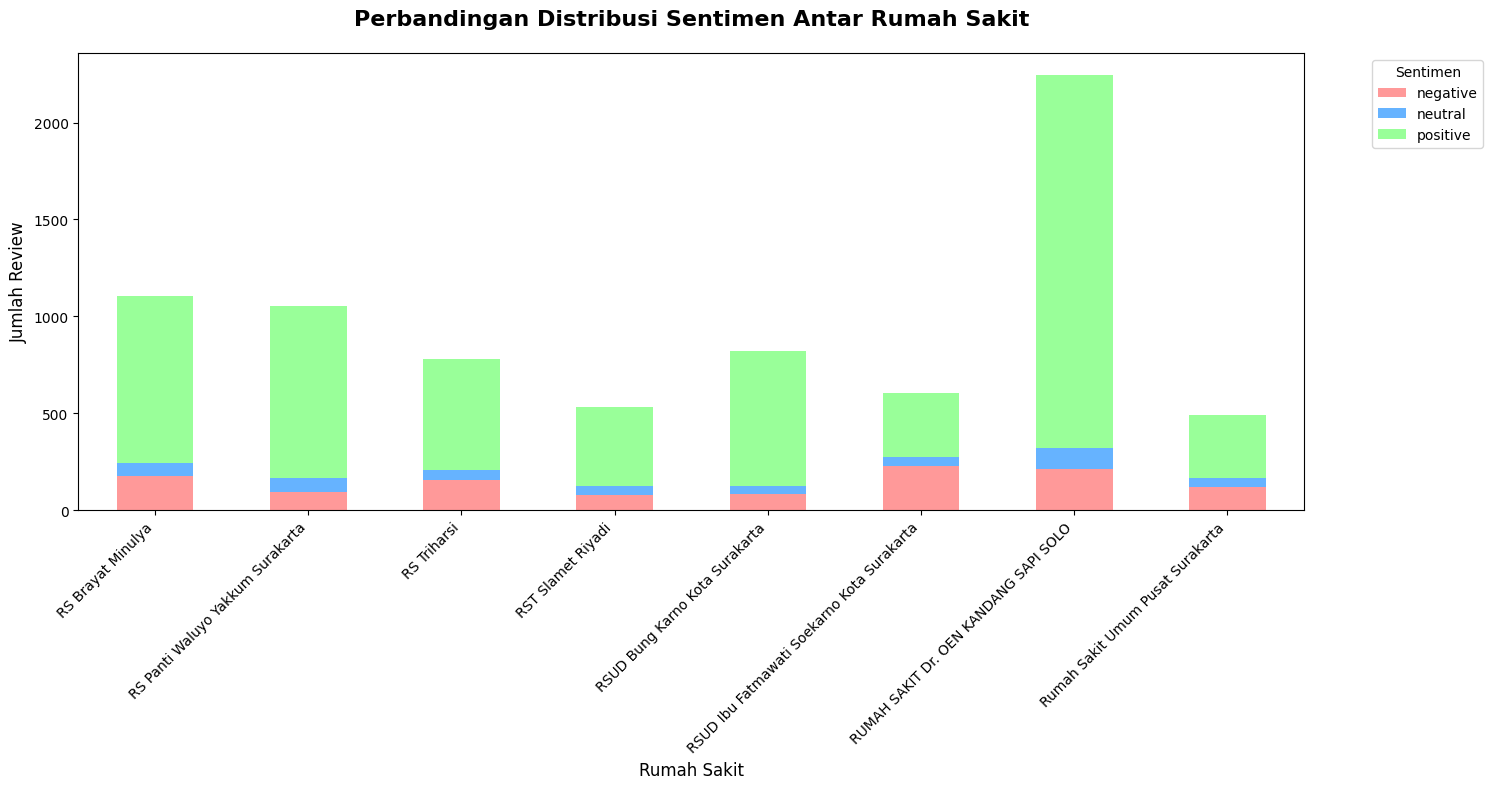


Persentase Sentimen per Rumah Sakit:

RS Brayat Minulya:
  positive: 78.2%
  negative: 15.7%
  neutral: 6.1%

RSUD Bung Karno Kota Surakarta:
  positive: 84.8%
  negative: 10.4%
  neutral: 4.9%

RUMAH SAKIT Dr. OEN KANDANG SAPI SOLO:
  positive: 85.8%
  negative: 9.4%
  neutral: 4.8%

RSUD Ibu Fatmawati Soekarno Kota Surakarta:
  positive: 54.8%
  negative: 37.1%
  neutral: 8.1%

RS Panti Waluyo Yakkum Surakarta:
  positive: 84.3%
  negative: 8.7%
  neutral: 6.9%

RST Slamet Riyadi:
  positive: 76.5%
  negative: 14.5%
  neutral: 9.0%

RS Triharsi:
  positive: 73.4%
  negative: 19.6%
  neutral: 7.0%

Rumah Sakit Umum Pusat Surakarta:
  positive: 66.6%
  negative: 23.8%
  neutral: 9.6%


In [16]:
# Stacked Bar Chart Perbandingan Sentimen Antar RS
sentiment_by_rs = data.groupby(['title', 'sentiment']).size().unstack(fill_value=0)

plt.figure(figsize=(15, 8))
sentiment_by_rs.plot(kind='bar', stacked=True, 
                    color=['#ff9999', '#66b3ff', '#99ff99'],
                    figsize=(15, 8))
plt.title('Perbandingan Distribusi Sentimen Antar Rumah Sakit', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Rumah Sakit', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Tampilkan persentase sentimen per RS
print("\nPersentase Sentimen per Rumah Sakit:")
print("="*50)
for rs in data['title'].unique():
    rs_data = data[data['title'] == rs]
    sentiment_pct = rs_data['sentiment'].value_counts(normalize=True) * 100
    print(f"\n{rs}:")
    for sentiment, pct in sentiment_pct.items():
        print(f"  {sentiment}: {pct:.1f}%")

# Distribusi Kategori

- Distribuis kategori secara umum  
- Distribusi kategori tiap rumah sakit  
- Diagram venn

In [17]:
from matplotlib_venn import venn2, venn2_circles, venn3, venn3_circles

## Umum

In [18]:
# Eksplorasi data kategori
print("Distribusi Kategori:")
print(f"Fasilitas (1): {data['fasilitas'].sum()} reviews")
print(f"Pelayanan (1): {data['pelayanan'].sum()} reviews")
print(f"Total reviews: {len(data)}")

# Cek kombinasi kategori
kombinasi = data.groupby(['fasilitas', 'pelayanan']).size()
print("\nKombinasi Kategori:")
print(kombinasi)

# Persentase
print("\nPersentase Kategori:")
print(f"Hanya Fasilitas: {len(data[(data['fasilitas'] == 1) & (data['pelayanan'] == 0)])} ({len(data[(data['fasilitas'] == 1) & (data['pelayanan'] == 0)])/len(data)*100:.1f}%)")
print(f"Hanya Pelayanan: {len(data[(data['fasilitas'] == 0) & (data['pelayanan'] == 1)])} ({len(data[(data['fasilitas'] == 0) & (data['pelayanan'] == 1)])/len(data)*100:.1f}%)")
print(f"Keduanya (Fasilitas & Pelayanan): {len(data[(data['fasilitas'] == 1) & (data['pelayanan'] == 1)])} ({len(data[(data['fasilitas'] == 1) & (data['pelayanan'] == 1)])/len(data)*100:.1f}%)")
print(f"Tidak ada kategori: {len(data[(data['fasilitas'] == 0) & (data['pelayanan'] == 0)])} ({len(data[(data['fasilitas'] == 0) & (data['pelayanan'] == 0)])/len(data)*100:.1f}%)")

Distribusi Kategori:
Fasilitas (1): 3064 reviews
Pelayanan (1): 7163 reviews
Total reviews: 7639

Kombinasi Kategori:
fasilitas  pelayanan
0          0              90
           1            4485
1          0             386
           1            2678
dtype: int64

Persentase Kategori:
Hanya Fasilitas: 386 (5.1%)
Hanya Pelayanan: 4485 (58.7%)
Keduanya (Fasilitas & Pelayanan): 2678 (35.1%)
Tidak ada kategori: 90 (1.2%)


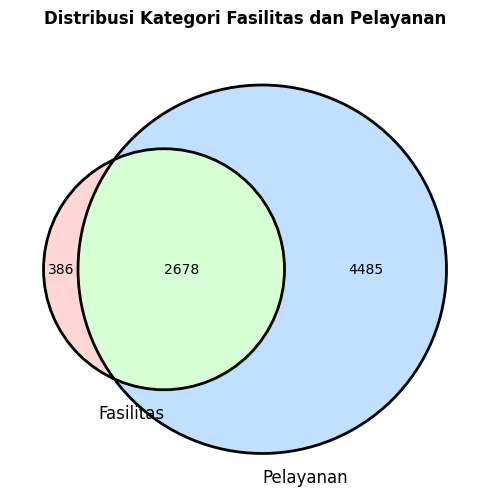

In [19]:
# Diagram Venn untuk Kategori Fasilitas dan Pelayanan
plt.figure(figsize=(5, 5))

# Hitung jumlah untuk setiap kategori
fasilitas_only = len(data[(data['fasilitas'] == 1) & (data['pelayanan'] == 0)])
pelayanan_only = len(data[(data['fasilitas'] == 0) & (data['pelayanan'] == 1)])
both_categories = len(data[(data['fasilitas'] == 1) & (data['pelayanan'] == 1)])

# Membuat diagram Venn
venn = venn2(subsets=(fasilitas_only, pelayanan_only, both_categories), 
             set_labels=('Fasilitas', 'Pelayanan'))

# Customize warna dan style
venn.get_patch_by_id('10').set_color('#ff9999')  # Fasilitas only
venn.get_patch_by_id('01').set_color('#66b3ff')  # Pelayanan only  
venn.get_patch_by_id('11').set_color('#99ff99')  # Both

# Tambahkan outline
venn2_circles(subsets=(fasilitas_only, pelayanan_only, both_categories))

plt.title('Distribusi Kategori Fasilitas dan Pelayanan', 
          fontsize=12, fontweight='bold', pad=20)

# Tambahkan keterangan persentase
total_with_categories = fasilitas_only + pelayanan_only + both_categories

plt.tight_layout()
plt.show()

## Per Rumah Sakit

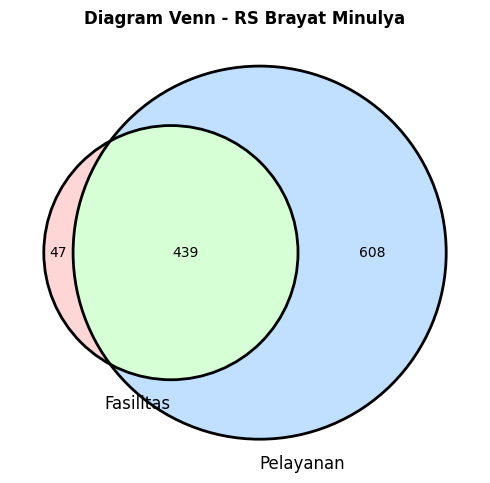

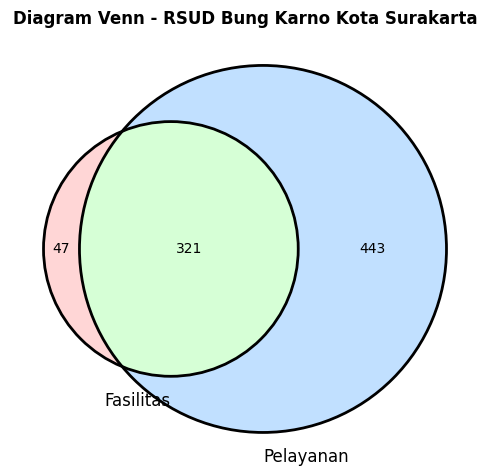

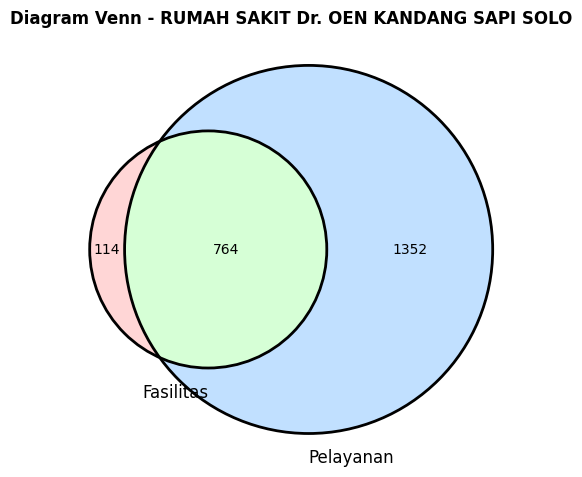

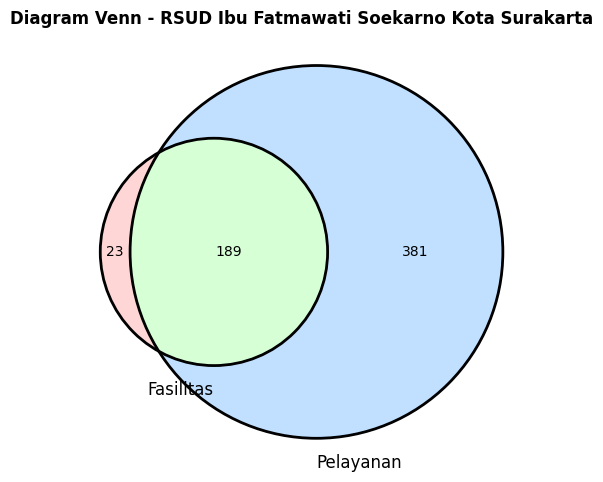

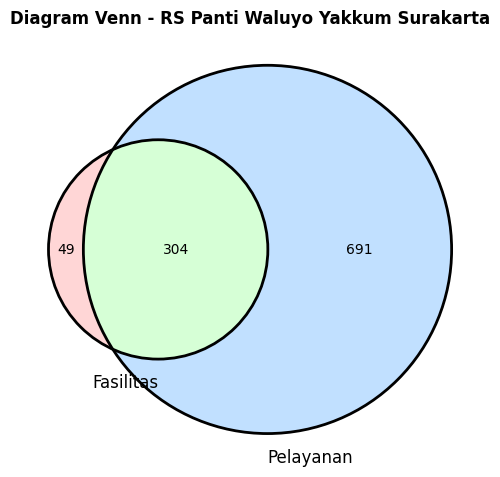

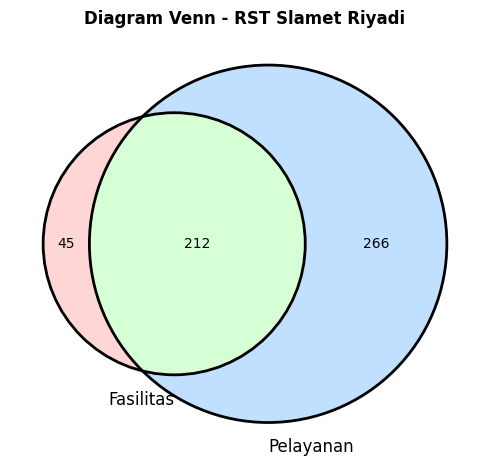

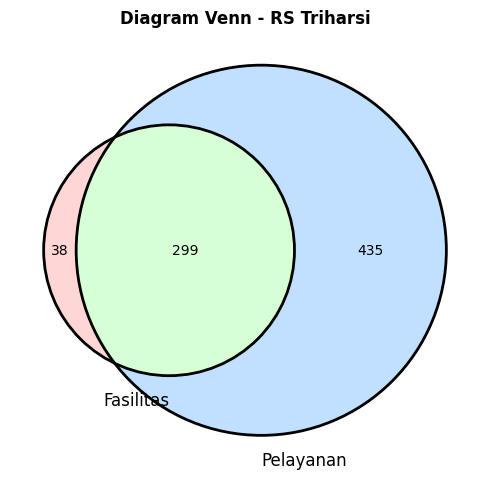

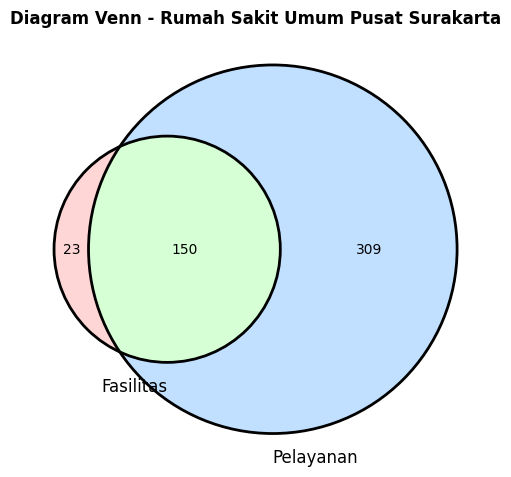

In [30]:
def venn_diagram_per_rs(data):
    rs_list = data['title'].unique()

    for rs in rs_list:
        # Filter data per RS
        rs_data = data[data['title'] == rs]

        # Hitung jumlah untuk setiap kategori
        fasilitas_only = len(rs_data[(rs_data['fasilitas'] == 1) & (rs_data['pelayanan'] == 0)])
        pelayanan_only = len(rs_data[(rs_data['fasilitas'] == 0) & (rs_data['pelayanan'] == 1)])
        both_categories = len(rs_data[(rs_data['fasilitas'] == 1) & (rs_data['pelayanan'] == 1)])

        # Buat figure baru untuk tiap RS
        plt.figure(figsize=(5, 5))

        # Buat diagram Venn jika ada data
        if fasilitas_only + pelayanan_only + both_categories > 0:
            venn = venn2(subsets=(fasilitas_only, pelayanan_only, both_categories),
                         set_labels=('Fasilitas', 'Pelayanan'))

            # Customize warna
            if venn.get_patch_by_id('10'): venn.get_patch_by_id('10').set_color('#ff9999')
            if venn.get_patch_by_id('01'): venn.get_patch_by_id('01').set_color('#66b3ff')
            if venn.get_patch_by_id('11'): venn.get_patch_by_id('11').set_color('#99ff99')

            # Tambahkan outline
            venn2_circles(subsets=(fasilitas_only, pelayanan_only, both_categories))
        else:
            plt.text(0.5, 0.5, 'Tidak ada data\nkategori', ha='center', va='center',
                     transform=plt.gca().transAxes, fontsize=12)

        plt.title(f'Diagram Venn - {rs}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

venn_diagram_per_rs(data)

NameError: name 'np' is not defined

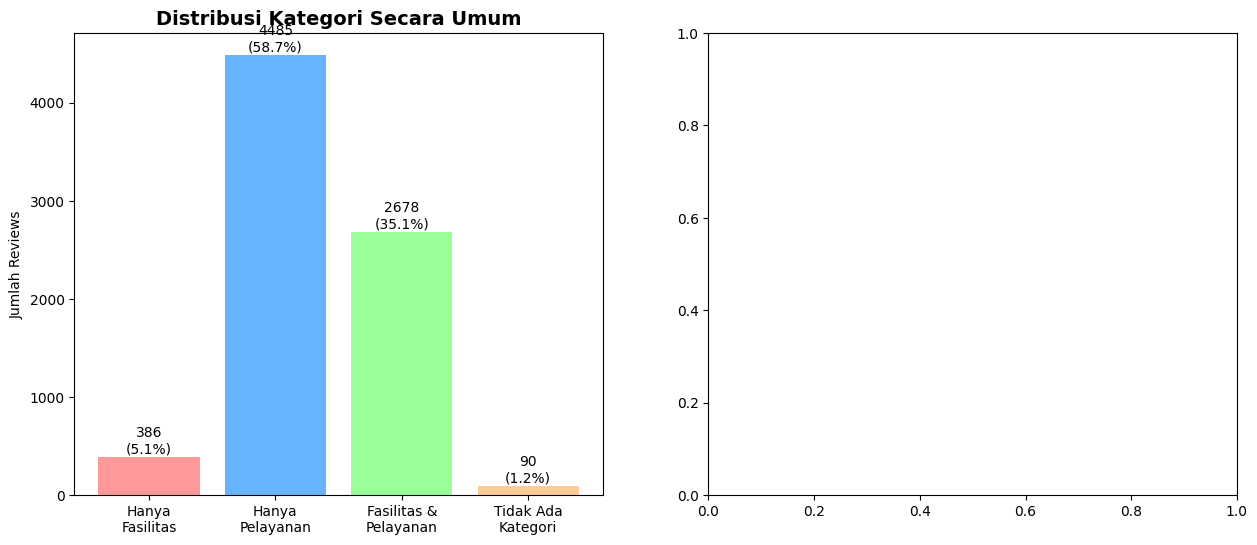

In [21]:
# Bar Chart Distribusi Kategori
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Distribusi kategori secara umum
categories = ['Hanya\nFasilitas', 'Hanya\nPelayanan', 'Fasilitas &\nPelayanan', 'Tidak Ada\nKategori']
counts = [
    len(data[(data['fasilitas'] == 1) & (data['pelayanan'] == 0)]),
    len(data[(data['fasilitas'] == 0) & (data['pelayanan'] == 1)]),
    len(data[(data['fasilitas'] == 1) & (data['pelayanan'] == 1)]),
    len(data[(data['fasilitas'] == 0) & (data['pelayanan'] == 0)])
]

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
bars1 = ax1.bar(categories, counts, color=colors)
ax1.set_title('Distribusi Kategori Secara Umum', fontsize=14, fontweight='bold')
ax1.set_ylabel('Jumlah Reviews')

# Tambahkan nilai di atas bar
for bar, count in zip(bars1, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{count}\n({count/len(data)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)

# Chart 2: Perbandingan antar RS
rs_category_data = []
rs_names = data['title'].unique()

for rs in rs_names:
    rs_data = data[data['title'] == rs]
    rs_counts = [
        len(rs_data[(rs_data['fasilitas'] == 1) & (rs_data['pelayanan'] == 0)]),
        len(rs_data[(rs_data['fasilitas'] == 0) & (rs_data['pelayanan'] == 1)]),
        len(rs_data[(rs_data['fasilitas'] == 1) & (rs_data['pelayanan'] == 1)]),
        len(rs_data[(rs_data['fasilitas'] == 0) & (rs_data['pelayanan'] == 0)])
    ]
    rs_category_data.append(rs_counts)

# Transpose untuk plotting
rs_category_data = np.array(rs_category_data).T

# Stacked bar chart
bottom = np.zeros(len(rs_names))
for i, (category, color) in enumerate(zip(categories, colors)):
    ax2.bar(rs_names, rs_category_data[i], bottom=bottom, label=category, color=color)
    bottom += rs_category_data[i]

ax2.set_title('Distribusi Kategori per Rumah Sakit', fontsize=14, fontweight='bold')
ax2.set_ylabel('Jumlah Reviews')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()